# Thrivot - Income Affordability: Classification Model

**What this notebook does.** Trains the **income-aware affordability classifier**: given a city's
characteristics **and a user's monthly income**, it outputs the probability (a 0–100 score) that
the household can afford that city.

**The key idea.** Each city is replicated across many sampled incomes ($1,800–$16,000/mo) and
labelled by whether that specific income covers the city's real cost of living. Because
`user_income_monthly` is an explicit input, the model learns how affordability changes *with
income* instead of memorising one fixed answer per city.

**Board-ready graphs in this notebook**
1. Class balance - *are the labels balanced?*
2. **Training curve** (log-loss vs boosting rounds) - *the model learning*
3. Confusion matrix + ROC curve - *accuracy & ranking quality*
4. Precision–Recall curve + score separation - *class separability*
5. **Income sweep** - *score rises and crosses 50% at the city's true cost: proof it learned income*

**Depends on** `model_cost.pkl` from the regression notebook (used only to show predicted cost in
the demo). If it is missing, this notebook trains a quick cost model so it still runs standalone.


## 1. Imports

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
)
from xgboost import XGBRegressor, XGBClassifier

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 5)
print("Libraries loaded.")

Libraries loaded.


## 2. Load data & rebuild the cost target

Same preparation as the regression notebook: fuse MIT non-housing costs with observed Zillow rent
into one monthly `cost_of_living_monthly`, in long format (one row per city per family profile).

In [2]:
DATA_PATH = Path("../data/cleaned_data/master_data_clean.csv")
df = pd.read_csv(DATA_PATH)

PROFILES = ["1p0c", "1p1c", "1p2c", "1p3c", "2p0c", "2p1c", "2p2c"]
PROFILE_ENCODING = {p: i for i, p in enumerate(PROFILES)}
CITY_COLS = [
    "state", "city", "city_state_key", "lat", "lng", "population",
    "violent_crime_rate", "property_crime_rate",
    "flood_risk_score", "wildfire_risk_score",
    "hurricane_risk_score", "tornado_risk_score",
    "median_family_income", "avg_monthly_rent",
]

frames = []
for p in PROFILES:
    block = df[CITY_COLS].copy()
    monthly_non_housing = (df[f"{p}_total_cost"] - df[f"{p}_housing_cost"]) / 12.0
    block["cost_of_living_monthly"] = monthly_non_housing + df["avg_monthly_rent"]
    block["family_profile"] = p
    block["family_profile_encoded"] = PROFILE_ENCODING[p]
    frames.append(block)
long_df = pd.concat(frames, ignore_index=True)

FEATURE_COLS = [
    "lat", "lng", "population",
    "violent_crime_rate", "property_crime_rate",
    "flood_risk_score", "wildfire_risk_score",
    "hurricane_risk_score", "tornado_risk_score",
    "median_family_income", "family_profile_encoded",
]
TARGET = "cost_of_living_monthly"
REQUIRED = [TARGET, "median_family_income", "lat", "lng",
            "flood_risk_score", "wildfire_risk_score",
            "hurricane_risk_score", "tornado_risk_score"]
model_df = long_df.dropna(subset=REQUIRED).reset_index(drop=True)
print(f"City-profile rows: {model_df.shape[0]:,}")

City-profile rows: 192,087


## 3. Load the cost model (from the regression notebook)

We only need it to display a predicted cost in the demo. If `model_cost.pkl` is missing, run the
regression notebook once to create it - or this cell trains a quick fallback so this notebook
still runs standalone.

In [3]:
COST_MODEL_PATH = Path("model_cost.pkl")
if COST_MODEL_PATH.exists():
    cost_model = joblib.load(COST_MODEL_PATH)
    print("Loaded model_cost.pkl (from the regression notebook).")
else:
    print("model_cost.pkl not found - training a quick cost model so this notebook is standalone.")
    cost_model = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=RANDOM_STATE, n_jobs=-1)
    cost_model.fit(model_df[FEATURE_COLS], model_df[TARGET])
    print("Cost model trained.")

Loaded model_cost.pkl (from the regression notebook).


## 4. Build a training set where income VARIES per city

Each city-profile is replicated at several sampled incomes, and the label is whether that
specific income covers that city's real cost. Income becomes an independent input the model must
reason about.

In [4]:
rng = np.random.default_rng(RANDOM_STATE)
N_INCOME_SAMPLES = 5  # each city-profile is shown at 5 different incomes

def sample_incomes(n):
    # Realistic monthly take-home income, log-uniform from $1,800 to $16,000.
    return np.exp(rng.uniform(np.log(1800), np.log(16000), size=n))

base = model_df[FEATURE_COLS + [TARGET, "city_state_key"]].reset_index(drop=True)
rep = base.loc[base.index.repeat(N_INCOME_SAMPLES)].reset_index(drop=True)
rep["user_income_monthly"] = sample_incomes(len(rep))
rep["affordable"] = (rep["user_income_monthly"] >= rep[TARGET]).astype(int)

CLF_FEATURES = FEATURE_COLS + ["user_income_monthly"]
print(f"Augmented rows: {len(rep):,}  (= {len(base):,} city-profiles x {N_INCOME_SAMPLES} incomes)")
print(f"Affordable share: {rep['affordable'].mean():.1%}")

Augmented rows: 960,435  (= 192,087 city-profiles x 5 incomes)
Affordable share: 45.5%


## 5. Class balance

A roughly even split between affordable / not affordable means the classifier cannot cheat by
always guessing one answer.

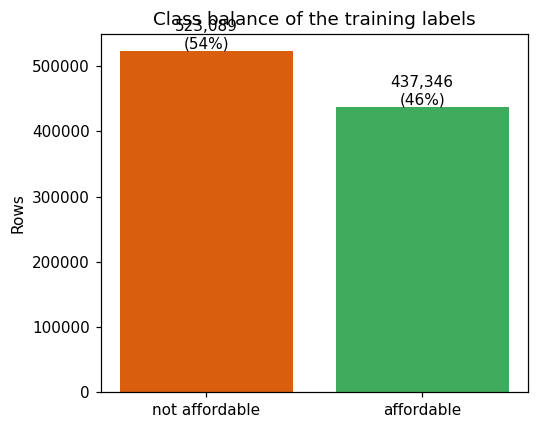

In [5]:
counts = rep["affordable"].value_counts().sort_index()
plt.figure(figsize=(5, 4))
plt.bar(["not affordable", "affordable"], counts.values, color=["#d95f0e", "#41ab5d"])
for i, v in enumerate(counts.values):
    plt.text(i, v, f"{v:,}\n({v / len(rep):.0%})", ha="center", va="bottom")
plt.ylabel("Rows")
plt.title("Class balance of the training labels")
plt.tight_layout()
plt.show()

## 6. City-grouped train / test split

Whole cities go entirely into train or test, never both - the honest way to measure how the
classifier performs on genuinely new places.

In [6]:
g = rep["city_state_key"]
sp = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr, te = next(sp.split(rep, rep["affordable"], g))
X_train, X_test = rep.iloc[tr][CLF_FEATURES], rep.iloc[te][CLF_FEATURES]
y_train, y_test = rep.iloc[tr]["affordable"], rep.iloc[te]["affordable"]
print(f"Train rows: {len(tr):,} | Test rows: {len(te):,} | "
      f"shared cities: {len(set(g.iloc[tr]) & set(g.iloc[te]))} (must be 0)")

Train rows: 768,145 | Test rows: 192,290 | shared cities: 0 (must be 0)


## 7. Train the classifier + training curve

We fit the income-aware classifier while recording **log-loss at every boosting round** for both
the training and validation sets. The curve falling and flattening is the "model learning" graph
for the research board.

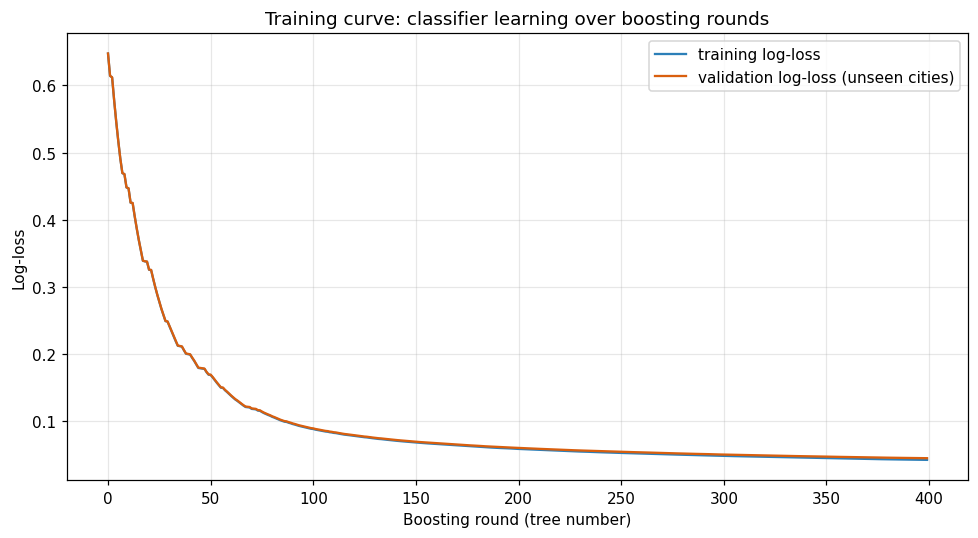

Final training log-loss:   0.0422
Final validation log-loss: 0.0448


In [7]:
clf = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric=["logloss", "error"],
    random_state=RANDOM_STATE, n_jobs=-1,
)
clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)
results = clf.evals_result()
train_loss = results["validation_0"]["logloss"]
test_loss = results["validation_1"]["logloss"]

plt.figure(figsize=(9, 5))
plt.plot(train_loss, label="training log-loss", color="#2c7fb8")
plt.plot(test_loss, label="validation log-loss (unseen cities)", color="#d95f0e")
plt.xlabel("Boosting round (tree number)")
plt.ylabel("Log-loss")
plt.title("Training curve: classifier learning over boosting rounds")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final training log-loss:   {train_loss[-1]:.4f}")
print(f"Final validation log-loss: {test_loss[-1]:.4f}")

## 8. Evaluate on unseen cities - confusion matrix & ROC

Accuracy and ROC-AUC, with the confusion matrix (right vs wrong) and ROC curve (ranking quality).

Accuracy = 0.984 | ROC-AUC = 0.999

                precision    recall  f1-score   support

not affordable       0.99      0.98      0.99    104546
    affordable       0.98      0.98      0.98     87744

      accuracy                           0.98    192290
     macro avg       0.98      0.98      0.98    192290
  weighted avg       0.98      0.98      0.98    192290



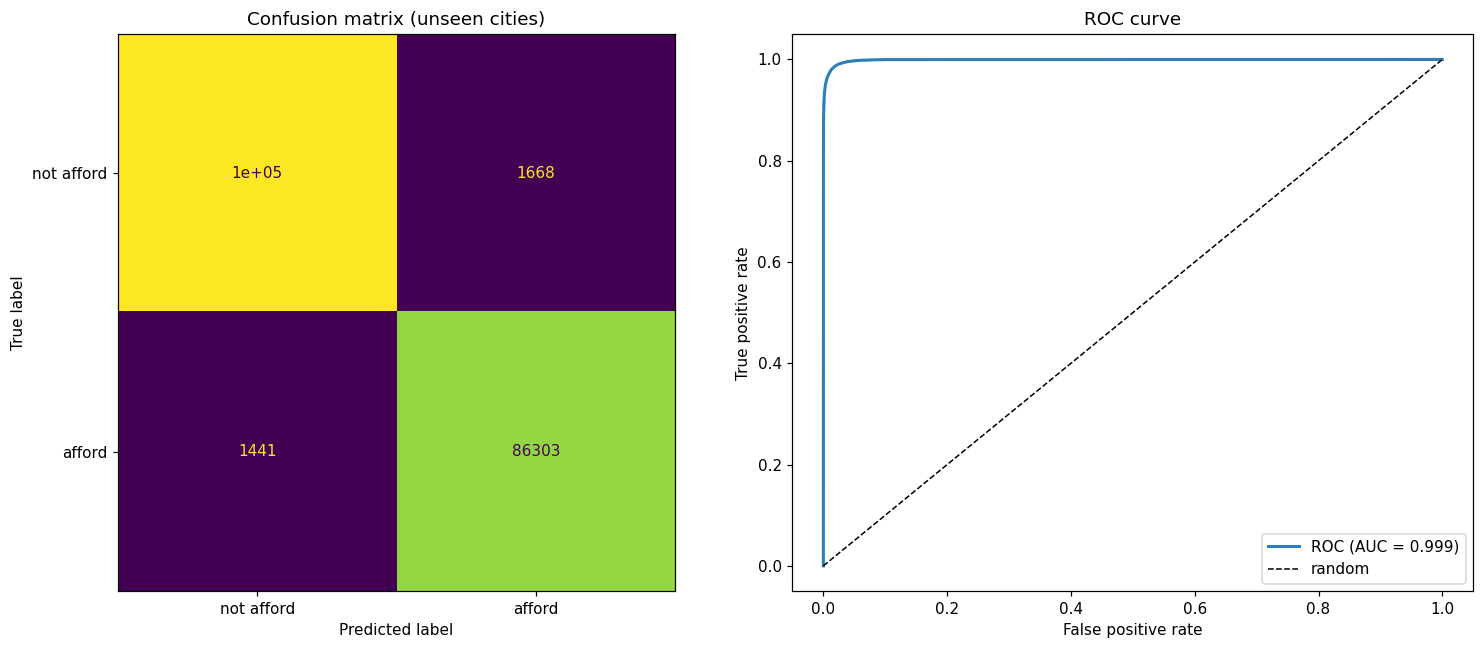

In [8]:
proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
acc = (pred == y_test.values).mean()
auc = roc_auc_score(y_test, proba)
print(f"Accuracy = {acc:.3f} | ROC-AUC = {auc:.3f}\n")
print(classification_report(y_test, pred, target_names=["not affordable", "affordable"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["not afford", "afford"], ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix (unseen cities)")
fpr, tpr, _ = roc_curve(y_test, proba)
axes[1].plot(fpr, tpr, color="#2c7fb8", linewidth=2, label=f"ROC (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="random")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve")
axes[1].legend()
plt.tight_layout()
plt.show()

## 9. Precision–Recall & score separation

The Precision–Recall curve is informative even when classes are balanced; the score histogram
shows how cleanly the model separates affordable from not-affordable cases.

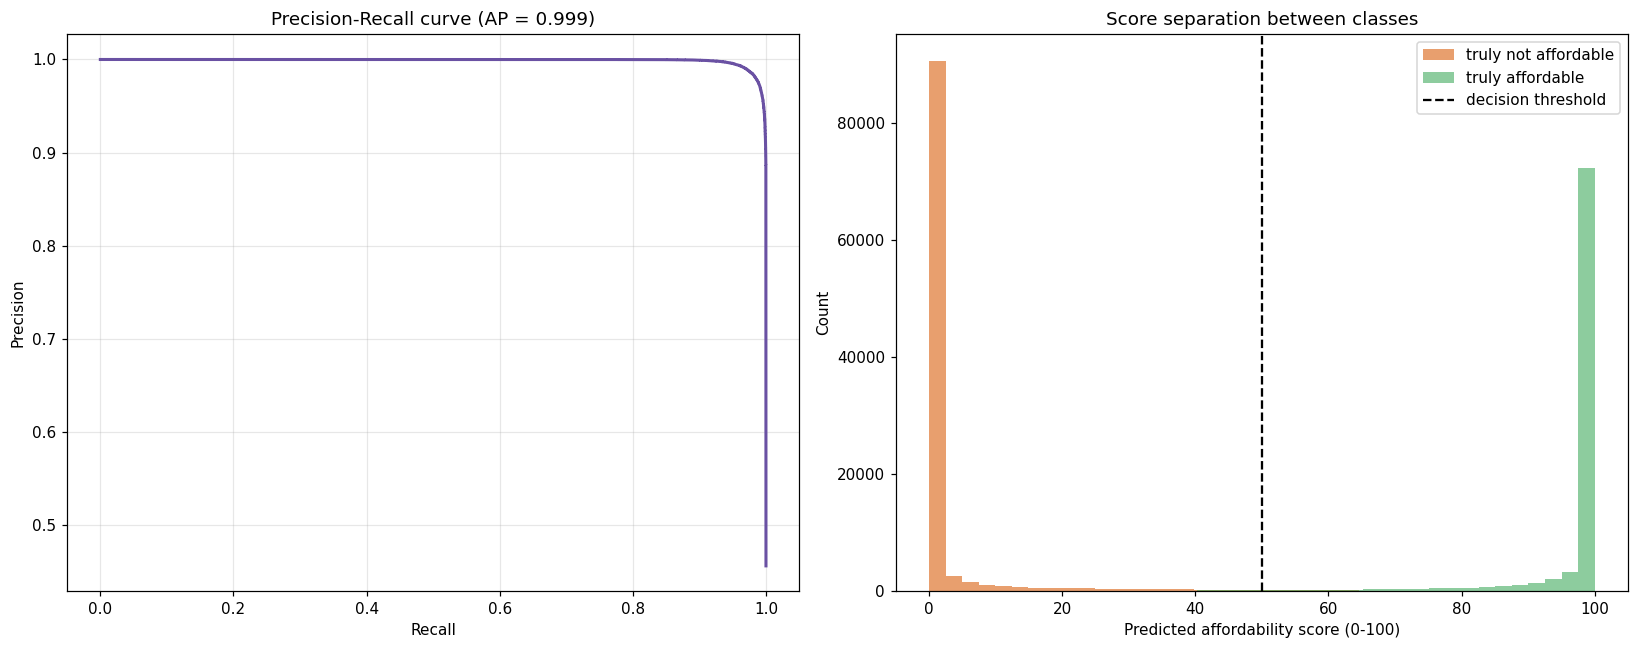

In [9]:
prec, rec, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(rec, prec, color="#6a51a3", linewidth=2)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall curve (AP = {ap:.3f})")
axes[0].grid(alpha=0.3)

axes[1].hist(proba[y_test.values == 0] * 100, bins=40, alpha=0.6,
             color="#d95f0e", label="truly not affordable")
axes[1].hist(proba[y_test.values == 1] * 100, bins=40, alpha=0.6,
             color="#41ab5d", label="truly affordable")
axes[1].axvline(50, color="black", linestyle="--", label="decision threshold")
axes[1].set_xlabel("Predicted affordability score (0-100)")
axes[1].set_ylabel("Count")
axes[1].set_title("Score separation between classes")
axes[1].legend()
plt.tight_layout()
plt.show()

## 10. What actually makes up the cost of living

This is the breakdown the app shows users - the **real monthly spending categories** (rent, food,
healthcare, childcare, transportation, taxes, other necessities) that add up to each city's cost of
living. **Rent is the single biggest piece.** These are the actual dollars; the classifier's only
job is to compare this total against the user's income.


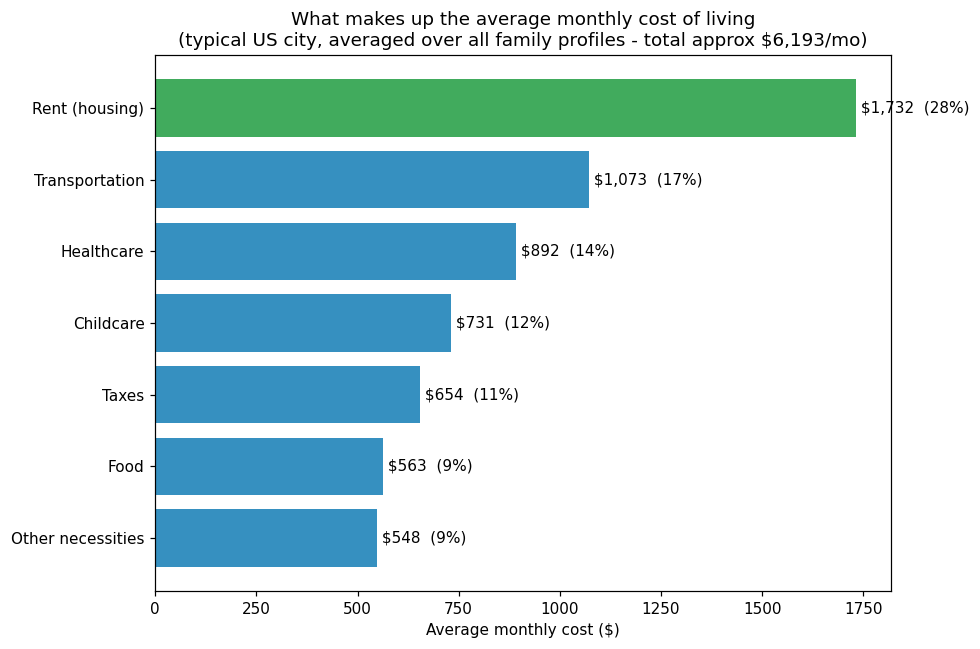

Average monthly cost-of-living breakdown:
Rent (housing)       1732
Transportation       1073
Healthcare            892
Childcare             731
Taxes                 654
Food                  563
Other necessities     548


In [14]:
# What actually makes up the monthly cost of living - the REAL spending categories.
# (Rent + the MIT non-housing components: food, healthcare, childcare, transport, taxes, etc.)
COMPONENTS = {
    "Food": "food_cost",
    "Healthcare": "healthcare_cost",
    "Childcare": "childcare_cost",
    "Transportation": "transportation_cost",
    "Taxes": "taxes",
    "Other necessities": "other_necessities_cost",
}

monthly = {}
# Rent comes straight from Zillow and is already monthly (same across family profiles).
monthly["Rent (housing)"] = df["avg_monthly_rent"].mean()
# Every other category is an annual MIT cost averaged across all 7 family profiles -> monthly.
for label, suffix in COMPONENTS.items():
    annual = pd.concat([df[f"{p}_{suffix}"] for p in PROFILES])
    monthly[label] = annual.mean() / 12.0

breakdown = pd.Series(monthly).sort_values()
total = breakdown.sum()

plt.figure(figsize=(9, 6))
bars = plt.barh(breakdown.index, breakdown.values,
                color=["#41ab5d" if i == "Rent (housing)" else "#3690c0" for i in breakdown.index])
for b, v in zip(bars, breakdown.values):
    plt.text(v, b.get_y() + b.get_height() / 2, f" ${v:,.0f}  ({v / total:.0%})", va="center")
plt.title("What makes up the average monthly cost of living\n"
          f"(typical US city, averaged over all family profiles - total approx ${total:,.0f}/mo)")
plt.xlabel("Average monthly cost ($)")
plt.tight_layout()
plt.show()

print("Average monthly cost-of-living breakdown:")
print(breakdown.sort_values(ascending=False).round(0).astype(int).to_string())


## 10b. Drivers of affordability aside from income - cost factors + weather

Affordability = does income cover the cost of living. So aside from income, the things that drive
affordability are **the cost-of-living factors** (rent, food, healthcare, childcare, transport,
taxes, other necessities) **and the weather risks** that tend to track with expensive places. This
chart shows how strongly each one moves the monthly cost - a higher value means that factor pushes
cost up and makes a city harder to afford. **Weather risks are highlighted in red.**


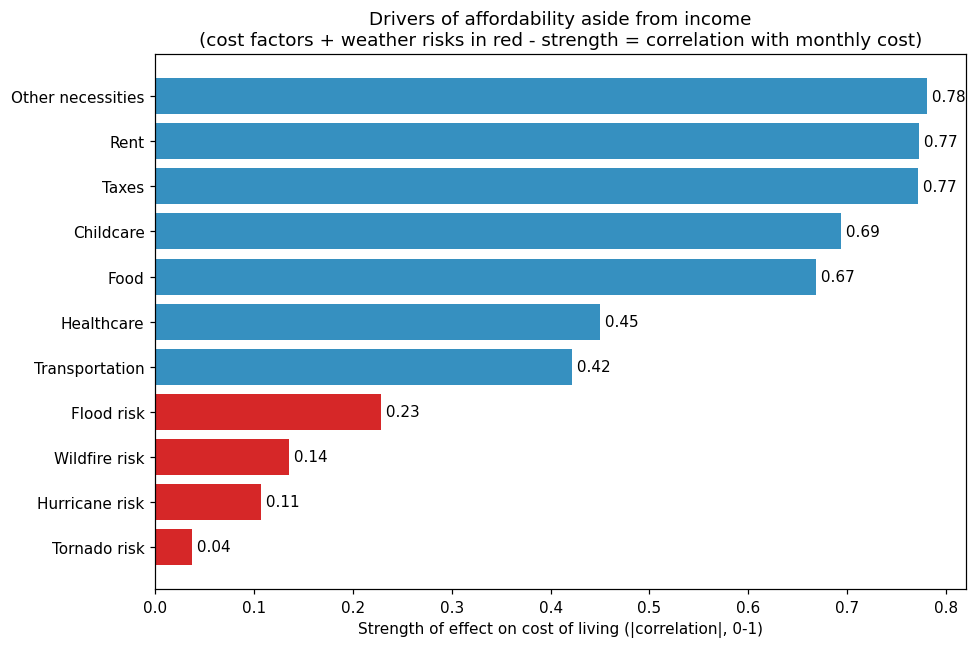

Factors ranked by how strongly they drive the cost of living:
Other necessities    0.781
Rent                 0.773
Taxes                0.772
Childcare            0.693
Food                 0.669
Healthcare           0.450
Transportation       0.422
Flood risk           0.228
Wildfire risk        0.136
Hurricane risk       0.107
Tornado risk         0.037


In [17]:
# Drivers of affordability aside from income = cost-of-living factors + weather risks.
# We measure each factor by how strongly it correlates with the monthly cost of living
# (higher = pushes cost up = harder to afford). Income / lat / lng / crime / population /
# family-profile are intentionally EXCLUDED.
WEATHER_FACTORS = {
    "Flood risk": "flood_risk_score",
    "Wildfire risk": "wildfire_risk_score",
    "Hurricane risk": "hurricane_risk_score",
    "Tornado risk": "tornado_risk_score",
}
COST_FACTORS = {
    "Food": "food_cost", "Healthcare": "healthcare_cost", "Childcare": "childcare_cost",
    "Transportation": "transportation_cost", "Taxes": "taxes",
    "Other necessities": "other_necessities_cost",
}

# Build one long table (city x family profile) of the factors + the resulting monthly cost.
factor_frames = []
for p in PROFILES:
    row = {"Rent": df["avg_monthly_rent"]}
    for label, suffix in COST_FACTORS.items():
        row[label] = df[f"{p}_{suffix}"] / 12.0
    for label, col in WEATHER_FACTORS.items():
        row[label] = df[col]
    row["cost_monthly"] = (df[f"{p}_total_cost"] - df[f"{p}_housing_cost"]) / 12.0 + df["avg_monthly_rent"]
    factor_frames.append(pd.DataFrame(row))
factors_df = pd.concat(factor_frames, ignore_index=True).dropna()

# Strength of each factor = |correlation| with the monthly cost of living.
corr = factors_df.corr()["cost_monthly"].drop("cost_monthly").abs().sort_values()
weather_names = set(WEATHER_FACTORS)
colors = ["#d62728" if name in weather_names else "#3690c0" for name in corr.index]

plt.figure(figsize=(9, 6))
bars = plt.barh(corr.index, corr.values, color=colors)
for b, v in zip(bars, corr.values):
    plt.text(v, b.get_y() + b.get_height() / 2, f" {v:.2f}", va="center")
plt.title("Drivers of affordability aside from income\n"
          "(cost factors + weather risks in red - strength = correlation with monthly cost)")
plt.xlabel("Strength of effect on cost of living (|correlation|, 0-1)")
plt.tight_layout()
plt.show()

print("Factors ranked by how strongly they drive the cost of living:")
print(corr.sort_values(ascending=False).round(3).to_string())


## 11. Proof it learned income: sweep income for one city

Fix one city and sweep income from low to high. The affordability score should climb from 0 to
100 and cross 50% right at the city's true cost - proof the model learned the relationship rather
than memorising a fixed answer. **This is the headline graph for the research board.**

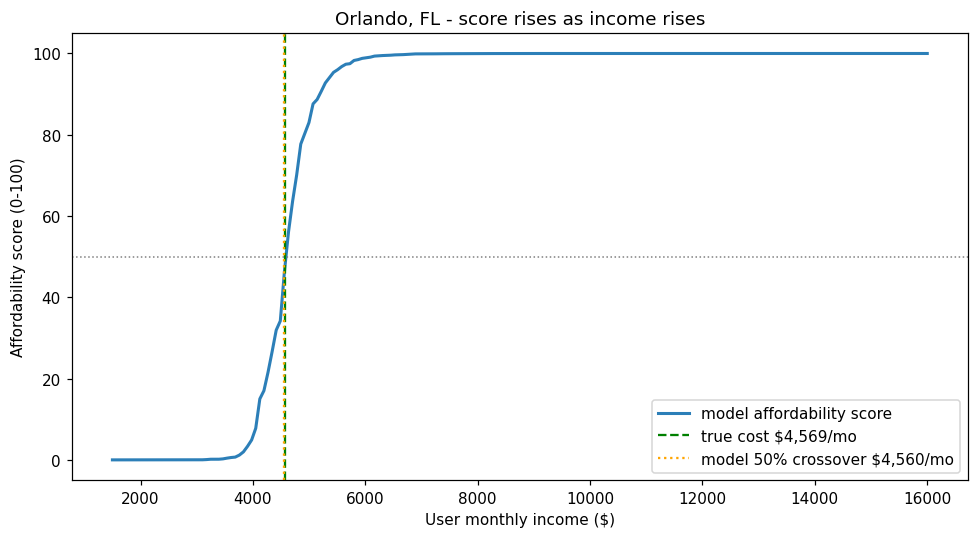

City: Orlando, FL | true cost $4,569/mo
Model crosses 50% affordable at $4,560/mo (should sit near the true cost).


In [11]:
demo_city = model_df.iloc[int(te[0])]
city_cost = float(demo_city[TARGET])

incomes = np.linspace(1500, 16000, 200)
grid = pd.DataFrame([demo_city[FEATURE_COLS].to_dict()] * len(incomes))
grid["user_income_monthly"] = incomes
sweep = clf.predict_proba(grid[CLF_FEATURES])[:, 1] * 100
crossover = incomes[np.argmin(np.abs(sweep - 50))]

plt.figure(figsize=(9, 5))
plt.plot(incomes, sweep, color="#2c7fb8", linewidth=2, label="model affordability score")
plt.axvline(city_cost, color="green", linestyle="--", label=f"true cost ${city_cost:,.0f}/mo")
plt.axvline(crossover, color="orange", linestyle=":", label=f"model 50% crossover ${crossover:,.0f}/mo")
plt.axhline(50, color="gray", linestyle=":", linewidth=1)
plt.xlabel("User monthly income ($)")
plt.ylabel("Affordability score (0-100)")
plt.title(f"{demo_city['city'].title()}, {demo_city['state']} - score rises as income rises")
plt.legend()
plt.tight_layout()
plt.show()

print(f"City: {demo_city['city'].title()}, {demo_city['state']} | true cost ${city_cost:,.0f}/mo")
print(f"Model crosses 50% affordable at ${crossover:,.0f}/mo (should sit near the true cost).")

## 12. Assess function & save the model

`assess_city_income()` is what the FastAPI backend calls: it predicts the city's cost and scores
affordability for a user's income. We save the classifier and its schema.

In [12]:
def assess_city_income(feature_row, user_monthly_income):
    """Cost is predicted from city characteristics; affordability is judged by the income-aware
    classifier using the USER's income as an explicit feature."""
    base_row = pd.DataFrame([feature_row])[FEATURE_COLS].copy()
    predicted_cost = float(cost_model.predict(base_row)[0])

    clf_row = base_row.copy()
    clf_row["user_income_monthly"] = user_monthly_income
    score = round(float(clf.predict_proba(clf_row[CLF_FEATURES])[0, 1]) * 100, 1)

    verdict = "Affordable" if score >= 70 else "Stretched" if score >= 40 else "Unaffordable"
    return {
        "predicted_cost_of_living": round(predicted_cost, 2),
        "user_monthly_income": user_monthly_income,
        "monthly_surplus": round(user_monthly_income - predicted_cost, 2),
        "affordability_score": score,
        "verdict": verdict,
    }

joblib.dump(clf, "model_afford_income.pkl")
schema = {
    "clf_features": CLF_FEATURES,
    "income_feature": "user_income_monthly",
    "profile_encoding": PROFILE_ENCODING,
    "metrics": {"accuracy": round(float(acc), 4), "roc_auc": round(float(auc), 4)},
    "note": "Income-aware affordability classifier trained on cities replicated across many "
            "sampled incomes; user_income_monthly is an explicit feature, "
            "label = income >= real cost of living.",
}
with open("features_income.json", "w") as fobj:
    json.dump(schema, fobj, indent=2)
print("Saved model_afford_income.pkl and features_income.json\n")

features_row = demo_city[FEATURE_COLS].to_dict()
for inc in [3000, 5000, 8000, 12000]:
    out = assess_city_income(features_row, inc)
    print(f"Income ${inc:>6,}/mo -> cost ${out['predicted_cost_of_living']:>7,.0f} | "
          f"score {out['affordability_score']:>5} | {out['verdict']}")

Saved model_afford_income.pkl and features_income.json

Income $ 3,000/mo -> cost $  4,595 | score   0.0 | Unaffordable
Income $ 5,000/mo -> cost $  4,595 | score  83.0 | Affordable
Income $ 8,000/mo -> cost $  4,595 | score 100.0 | Affordable
Income $12,000/mo -> cost $  4,595 | score 100.0 | Affordable
